In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as scp
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid.inset_locator import inset_axes
import matplotlib.patches as mpatches
import igraph
import scipy.stats as st
import bbknn
import os

from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from scipy.sparse import vstack


In [2]:
PCA = 50

# Global

In [3]:
if not os.path.isdir("plots/global/embryo_projection"):
    os.mkdir("plots/global/embryo_projection")

In [4]:
adata_embryo = scp.read("results/embryo/Embryo_corrected.h5ad")
adata_gastruloid = scp.read("results/QC.h5ad")

In [5]:
common_genes_embryo = [i in adata_gastruloid.var.index.values for i in adata_embryo.var.index.values]
common_genes_gastruloids = [i in adata_embryo.var.index.values for i in adata_gastruloid.var.index.values]

In [6]:
#Get to the common number of genes
adata_embryo = adata_embryo[:,common_genes_embryo]
adata_gastruloid = adata_gastruloid[:,common_genes_gastruloids]

## PCA embryo

In [7]:
scp.pp.highly_variable_genes(adata_embryo,flavor="seurat")
X = adata_embryo.X[:,adata_embryo.var.loc[:,"highly_variable"]]

Trying to set attribute `.uns` of view, copying.


In [8]:
m = TruncatedSVD(PCA)
m.fit(X)
X_pca_embryo = m.transform(X)

## Project gastruloids over PCA of the embryo

In [9]:
X = adata_gastruloid.X[:,adata_embryo.var.loc[:,"highly_variable"]]

In [10]:
X_pca_gastruloid = m.transform(X)

## Project over the UMAP

In [11]:
adata_embryo.obsm

AxisArrays with keys: X_umap_original

In [12]:
UMAP_embryo = adata_embryo.obsm["X_umap_original"]

m = KNeighborsRegressor(3,metric="correlation")
m.fit(X_pca_embryo,UMAP_embryo)

KNeighborsRegressor(metric='correlation', n_neighbors=3)

In [13]:
UMAP_gastruloid = m.predict(X_pca_gastruloid)

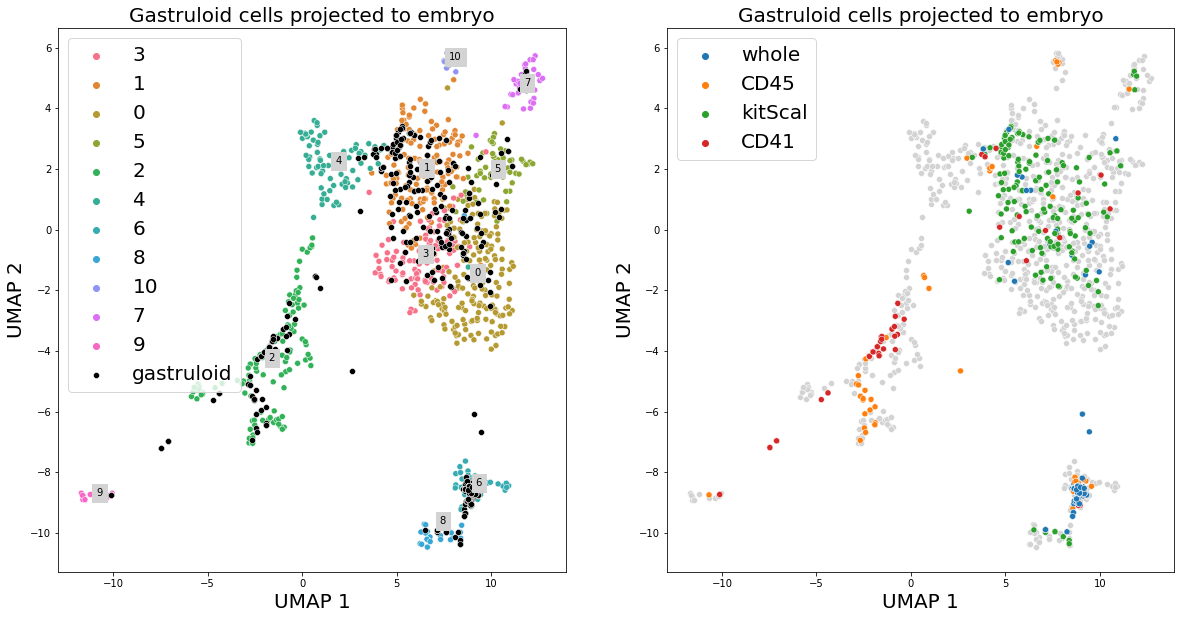

In [14]:
fig,ax = plt.subplots(1,2,figsize=[20,10])

# Clusters
adata_embryo.obs.loc[:,"Louvain Cluster"] = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
hue = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],hue=hue,ax=ax[0])
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],color="black",ax=ax[0],label="gastruloid")
for cluster in hue.unique():
    x = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,0].mean()
    y = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,1].mean()
    ax[0].text(x,y,cluster,backgroundcolor="lightgrey")
ax[0].legend(fontsize=20)
ax[0].set_xlabel("UMAP 1",fontsize=20)
ax[0].set_ylabel("UMAP 2",fontsize=20)
ax[0].set_title("Gastruloid cells projected to embryo",fontsize=20)

# Times
hue = adata_embryo.obs.loc[:,"Time"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],color="lightgrey",ax=ax[1])
hue = adata_gastruloid.obs.loc[:,"Condition"].astype(str)
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],hue=hue,ax=ax[1])
ax[1].legend(fontsize=20)
ax[1].set_xlabel("UMAP 1",fontsize=20)
ax[1].set_ylabel("UMAP 2",fontsize=20)
ax[1].set_title("Gastruloid cells projected to embryo",fontsize=20)

fig.savefig("plots/global/embryo_projection/embryo_umap_projection.png",bbox_inches="tight")

## Classify them in clusters

In [15]:
cluster_embryo = adata_embryo.obs.loc[:,["Louvain Cluster"]].astype(int).astype(str)

m = KNeighborsClassifier(3,metric="correlation")
m.fit(X_pca_embryo,cluster_embryo)

KNeighborsClassifier(metric='correlation', n_neighbors=3)

In [16]:
cluster_gastruloid = m.predict(X_pca_gastruloid)

In [17]:
adata_gastruloid.obs["clusters_from_embryo"] = cluster_gastruloid

Trying to set attribute `.obs` of view, copying.


In [18]:
matrix = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).count().iloc[:,0].unstack().transpose()
matrix = matrix/matrix.sum(axis=0)

In [19]:
adata_gastruloid.obs["correlation"] = m.kneighbors(X_pca_gastruloid)[0].mean(axis=1)
matrix2 = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).mean().loc[:,"correlation"].unstack().transpose()

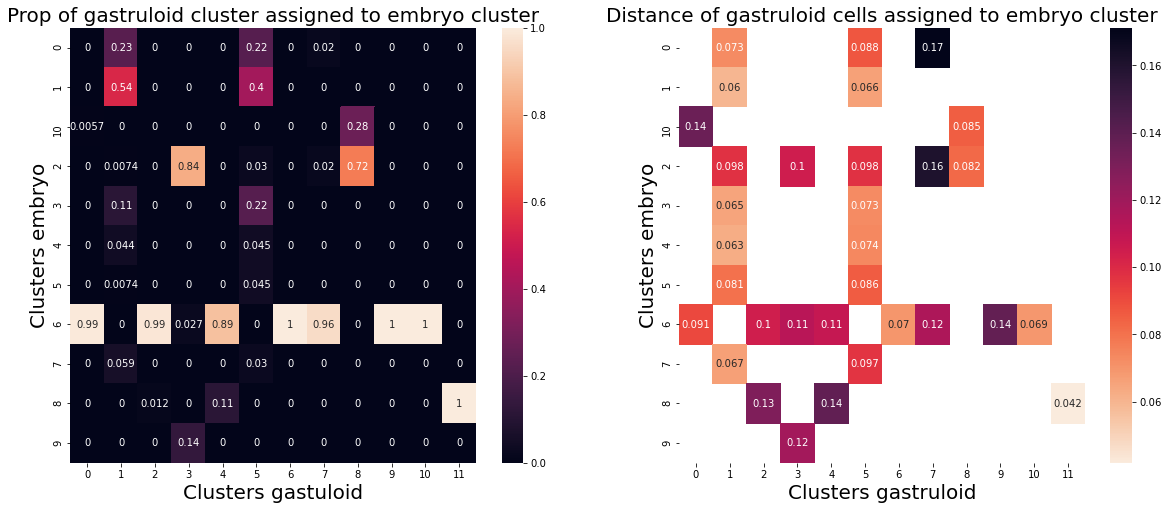

In [20]:
fig,ax = plt.subplots(1,2,figsize=[20,8])

sns.heatmap(matrix,annot=True,ax=ax[0])
ax[0].set_xlabel("Clusters gastuloid",fontsize=20)
ax[0].set_ylabel("Clusters embryo",fontsize=20)
ax[0].set_title("Prop of gastruloid cluster assigned to embryo cluster",fontsize=20)

sns.heatmap(matrix2,annot=True,ax=ax[1],cmap=sns.color_palette("rocket_r", as_cmap=True))
ax[1].set_xlabel("Clusters gastruloid",fontsize=20)
ax[1].set_ylabel("Clusters embryo",fontsize=20)
ax[1].set_title("Distance of gastruloid cells assigned to embryo cluster",fontsize=20)

fig.savefig("plots/global/embryo_projection/embryo_clusters_overlap.png",bbox_inches="tight")

## Paga clusters relationship

In [21]:
X = vstack((adata_embryo.X,adata_gastruloid.X)).tocsr()

In [22]:
obs1 = adata_embryo.obs
obs2 = adata_gastruloid.obs

obs = obs1.append(obs2)

In [23]:
var = adata_embryo.var

In [24]:
adata_integrated = scp.AnnData(X)
adata_integrated.obs = obs
adata_integrated.var = var

In [25]:
#Merge both tags in one column
embryo_cells = np.invert(pd.isna(adata_integrated.obs.loc[:,"Louvain Cluster"].values))
adata_integrated.obs.loc[embryo_cells,"combined_clusters"] = ["embryo_"+str(i) for i in adata_integrated.obs.loc[embryo_cells,"Louvain Cluster"]]
embryo_cells = np.invert(pd.isna(adata_integrated.obs.loc[:,"leiden_global"]))
adata_integrated.obs.loc[embryo_cells,"combined_clusters"] = ["gastruloid_"+str(i) for i in adata_integrated.obs.loc[embryo_cells,"leiden_global"]]

... storing 'Louvain Cluster' as categorical
... storing 'Time' as categorical
... storing 'Cell' as categorical
... storing 'Plate' as categorical
... storing 'Condition' as categorical
... storing 'BiologicalSample' as categorical
... storing 'Flow Cytommetry File' as categorical
... storing 'leiden_global' as categorical
... storing 'clusters_from_embryo' as categorical
... storing 'combined_clusters' as categorical


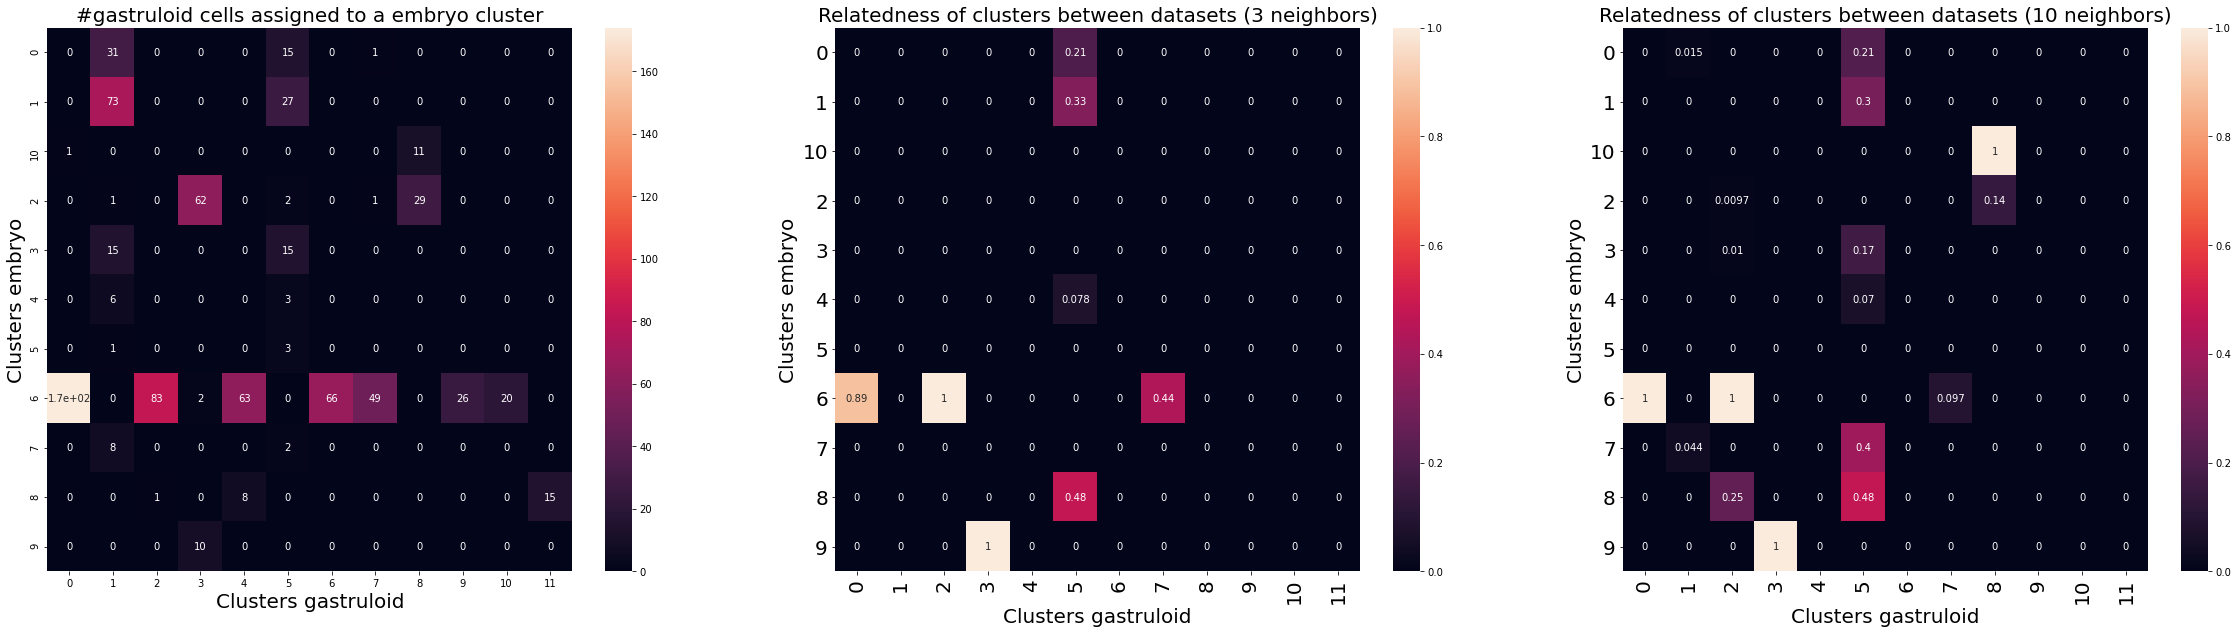

In [26]:
fig,ax = plt.subplots(1,3,figsize=[40,10])

#Plot count matrix
matrix = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).count().iloc[:,0].unstack().transpose()
matrix = matrix.sort_index()
sns.heatmap(matrix,annot=True,ax=ax[0],)
ax[0].set_ylabel("Clusters embryo",fontsize=20)
ax[0].set_xlabel("Clusters gastruloid",fontsize=20)
ax[0].set_title("#gastruloid cells assigned to a embryo cluster",fontsize=20)

#Compute paga
scp.pp.highly_variable_genes(adata_integrated)
scp.pp.pca(adata_integrated,n_comps=PCA)
scp.pp.neighbors(adata_integrated,n_neighbors=3,metric="correlation")
scp.tl.paga(adata_integrated,"combined_clusters");
#Get matrix
cat = adata_integrated.obs.loc[:,"combined_clusters"].cat.categories.values
data = pd.DataFrame(adata_integrated.uns["paga"]["connectivities"].todense(),index=cat,columns=cat)
data = data.iloc[:,11:].iloc[:11,:]
data = data.sort_index()
#Plot
sns.heatmap(data,annot=True,ax=ax[1])
labels = ax[1].get_xticklabels()
ax[1].set_xticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
labels = ax[1].get_yticklabels()
ax[1].set_yticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
ax[1].set_ylabel("Clusters embryo",fontsize=20)
ax[1].set_xlabel("Clusters gastruloid",fontsize=20)
ax[1].set_title("Relatedness of clusters between datasets (3 neighbors)",fontsize=20)

#Compute paga
scp.pp.highly_variable_genes(adata_integrated)
scp.pp.pca(adata_integrated,n_comps=PCA)
scp.pp.neighbors(adata_integrated,n_neighbors=10,metric="correlation")
scp.tl.paga(adata_integrated,"combined_clusters");
#Get matrix
cat = adata_integrated.obs.loc[:,"combined_clusters"].cat.categories.values
data = pd.DataFrame(adata_integrated.uns["paga"]["connectivities"].todense(),index=cat,columns=cat)
data = data.iloc[:,11:].iloc[:11,:]
data = data.sort_index()
#Plot
sns.heatmap(data,annot=True,ax=ax[2])
labels = ax[2].get_xticklabels()
ax[2].set_xticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
labels = ax[2].get_yticklabels()
ax[2].set_yticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
ax[2].set_ylabel("Clusters embryo",fontsize=20)
ax[2].set_xlabel("Clusters gastruloid",fontsize=20)
ax[2].set_title("Relatedness of clusters between datasets (10 neighbors)",fontsize=20)

fig.savefig("plots/global/embryo_projection/relatedness_between_clusters.png",bbox_inches="tight")
fig.show()

# Sorted

In [27]:
if not os.path.isdir("plots/sorted/embryo_projection"):
    os.mkdir("plots/sorted/embryo_projection")

In [28]:
adata_embryo = scp.read("results/embryo/Embryo_corrected.h5ad")
adata_gastruloid = scp.read("results/subSamples/sorted/sorted.h5ad")

In [29]:
common_genes_embryo = [i in adata_gastruloid.var.index.values for i in adata_embryo.var.index.values]
common_genes_gastruloids = [i in adata_embryo.var.index.values for i in adata_gastruloid.var.index.values]

In [30]:
#Get to the common number of genes
adata_embryo = adata_embryo[:,common_genes_embryo]
adata_gastruloid = adata_gastruloid[:,common_genes_gastruloids]

## PCA embryo

In [31]:
scp.pp.highly_variable_genes(adata_embryo,flavor="seurat")
X = adata_embryo.X[:,adata_embryo.var.loc[:,"highly_variable"]]

Trying to set attribute `.uns` of view, copying.


In [32]:
m = TruncatedSVD(PCA)
m.fit(X)
X_pca_embryo = m.transform(X)

## Project gastruloids over PCA of the embryo

In [33]:
X = adata_gastruloid.X[:,adata_embryo.var.loc[:,"highly_variable"]]

In [34]:
X_pca_gastruloid = m.transform(X)

## Project over the UMAP

In [35]:
UMAP_embryo = adata_embryo.obsm["X_umap_original"]

m = KNeighborsRegressor(3,metric="correlation")
m.fit(X_pca_embryo,UMAP_embryo)

KNeighborsRegressor(metric='correlation', n_neighbors=3)

In [36]:
UMAP_gastruloid = m.predict(X_pca_gastruloid)

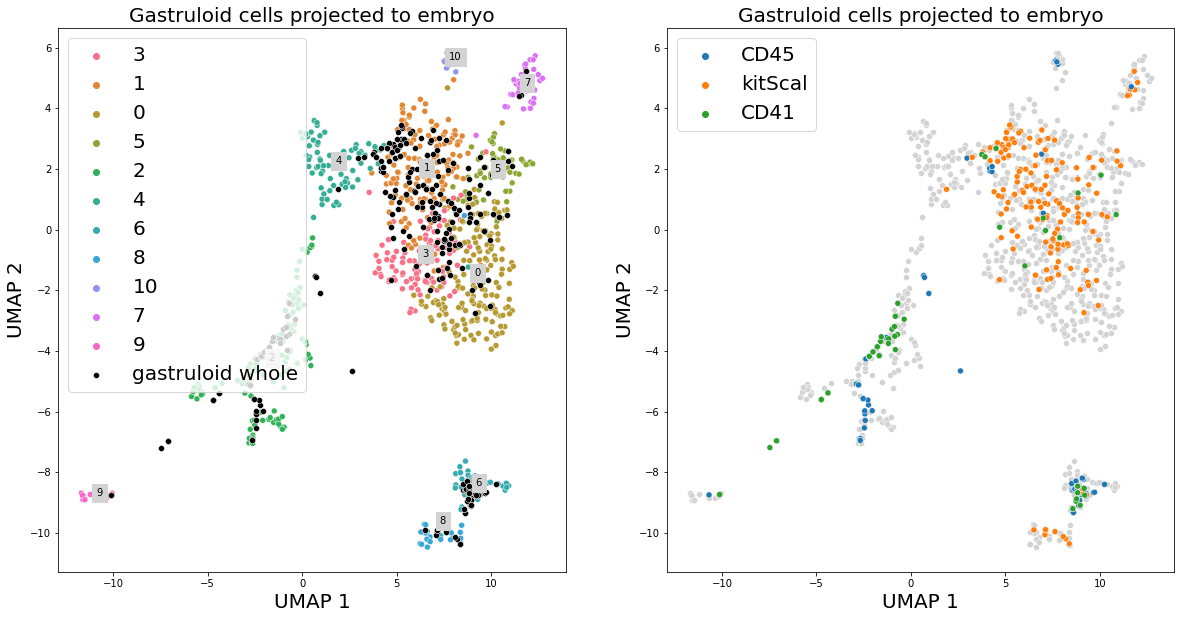

In [37]:
fig,ax = plt.subplots(1,2,figsize=[20,10])

# Clusters
adata_embryo.obs.loc[:,"Louvain Cluster"] = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
hue = adata_embryo.obs.loc[:,"Louvain Cluster"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],hue=hue,ax=ax[0])
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],color="black",ax=ax[0],label="gastruloid whole")
for cluster in hue.unique():
    x = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,0].mean()
    y = UMAP_embryo[adata_embryo.obs.loc[:,"Louvain Cluster"]==cluster,:][:,1].mean()
    ax[0].text(x,y,cluster,backgroundcolor="lightgrey")
ax[0].legend(fontsize=20)
ax[0].set_xlabel("UMAP 1",fontsize=20)
ax[0].set_ylabel("UMAP 2",fontsize=20)
ax[0].set_title("Gastruloid cells projected to embryo",fontsize=20)

# Times
hue = adata_embryo.obs.loc[:,"Time"].astype(str)
sns.scatterplot(x=UMAP_embryo[:,0],y=UMAP_embryo[:,1],color="lightgrey",ax=ax[1])
hue = adata_gastruloid.obs.loc[:,"Condition"].astype(str)
sns.scatterplot(x=UMAP_gastruloid[:,0],y=UMAP_gastruloid[:,1],hue=hue,ax=ax[1])
ax[1].legend(fontsize=20)
ax[1].set_xlabel("UMAP 1",fontsize=20)
ax[1].set_ylabel("UMAP 2",fontsize=20)
ax[1].set_title("Gastruloid cells projected to embryo",fontsize=20)

fig.savefig("plots/sorted/embryo_projection/embryo_umap_projection.png",bbox_inches="tight")

## Classify them in clusters

In [38]:
cluster_embryo = adata_embryo.obs.loc[:,["Louvain Cluster"]].astype(int).astype(str)

m = KNeighborsClassifier(3,metric="correlation")
m.fit(X_pca_embryo,cluster_embryo)

KNeighborsClassifier(metric='correlation', n_neighbors=3)

In [39]:
cluster_gastruloid = m.predict(X_pca_gastruloid)

In [40]:
adata_gastruloid.obs["clusters_from_embryo"] = cluster_gastruloid

Trying to set attribute `.obs` of view, copying.


In [41]:
matrix = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).count().iloc[:,0].unstack().transpose()
matrix = matrix/matrix.sum(axis=0)

In [42]:
adata_gastruloid.obs["correlation"] = m.kneighbors(X_pca_gastruloid)[0].mean(axis=1)
matrix2 = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).mean().loc[:,"correlation"].unstack().transpose()

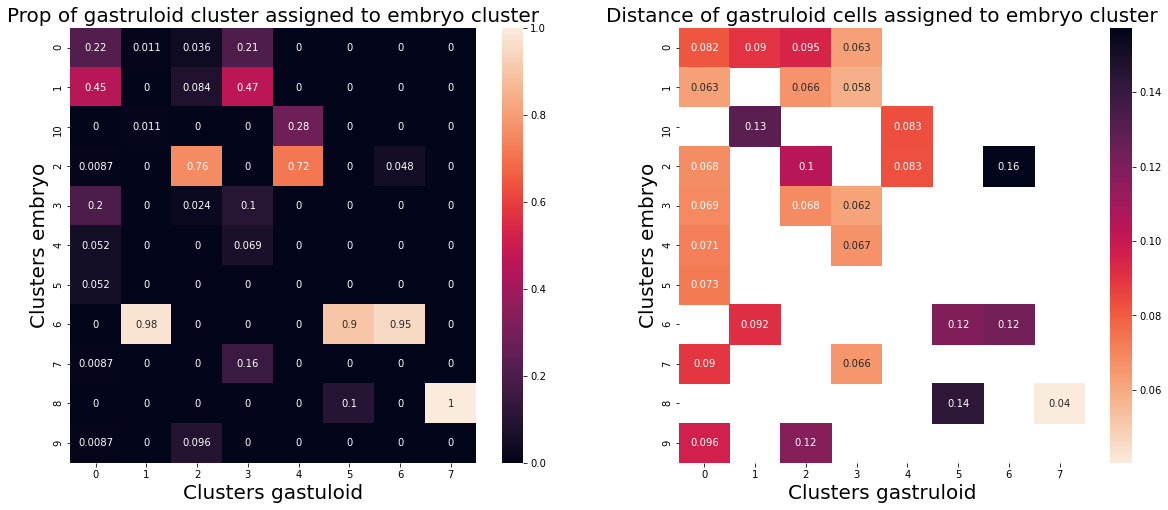

In [43]:
fig,ax = plt.subplots(1,2,figsize=[20,8])

sns.heatmap(matrix,annot=True,ax=ax[0])
ax[0].set_xlabel("Clusters gastuloid",fontsize=20)
ax[0].set_ylabel("Clusters embryo",fontsize=20)
ax[0].set_title("Prop of gastruloid cluster assigned to embryo cluster",fontsize=20)

sns.heatmap(matrix2,annot=True,ax=ax[1],cmap=sns.color_palette("rocket_r", as_cmap=True))
ax[1].set_xlabel("Clusters gastruloid",fontsize=20)
ax[1].set_ylabel("Clusters embryo",fontsize=20)
ax[1].set_title("Distance of gastruloid cells assigned to embryo cluster",fontsize=20)

fig.savefig("plots/sorted/embryo_projection/embryo_clusters_overlap.png",bbox_inches="tight")

## Paga clusters relationship

In [44]:
X = vstack((adata_embryo.X,adata_gastruloid.X)).tocsr()

In [45]:
obs1 = adata_embryo.obs
obs2 = adata_gastruloid.obs

obs = obs1.append(obs2)

In [46]:
var = adata_embryo.var

In [47]:
adata_integrated = scp.AnnData(X)
adata_integrated.obs = obs
adata_integrated.var = var

In [48]:
#Merge both tags in one column
embryo_cells = np.invert(pd.isna(adata_integrated.obs.loc[:,"Louvain Cluster"].values))
adata_integrated.obs.loc[embryo_cells,"combined_clusters"] = ["embryo_"+str(i) for i in adata_integrated.obs.loc[embryo_cells,"Louvain Cluster"]]
embryo_cells = np.invert(pd.isna(adata_integrated.obs.loc[:,"leiden_global"]))
adata_integrated.obs.loc[embryo_cells,"combined_clusters"] = ["gastruloid_"+str(i) for i in adata_integrated.obs.loc[embryo_cells,"leiden_global"]]

In [49]:
scp.pp.highly_variable_genes(adata_integrated,flavor="seurat")
scp.pp.pca(adata_integrated,n_comps=12)
scp.pp.neighbors(adata_integrated,n_neighbors=15,metric="correlation")
scp.tl.paga(adata_integrated,"combined_clusters");

... storing 'Louvain Cluster' as categorical
... storing 'Time' as categorical
... storing 'Cell' as categorical
... storing 'Plate' as categorical
... storing 'Condition' as categorical
... storing 'BiologicalSample' as categorical
... storing 'Flow Cytommetry File' as categorical
... storing 'leiden_global' as categorical
... storing 'clusters_from_embryo' as categorical
... storing 'combined_clusters' as categorical


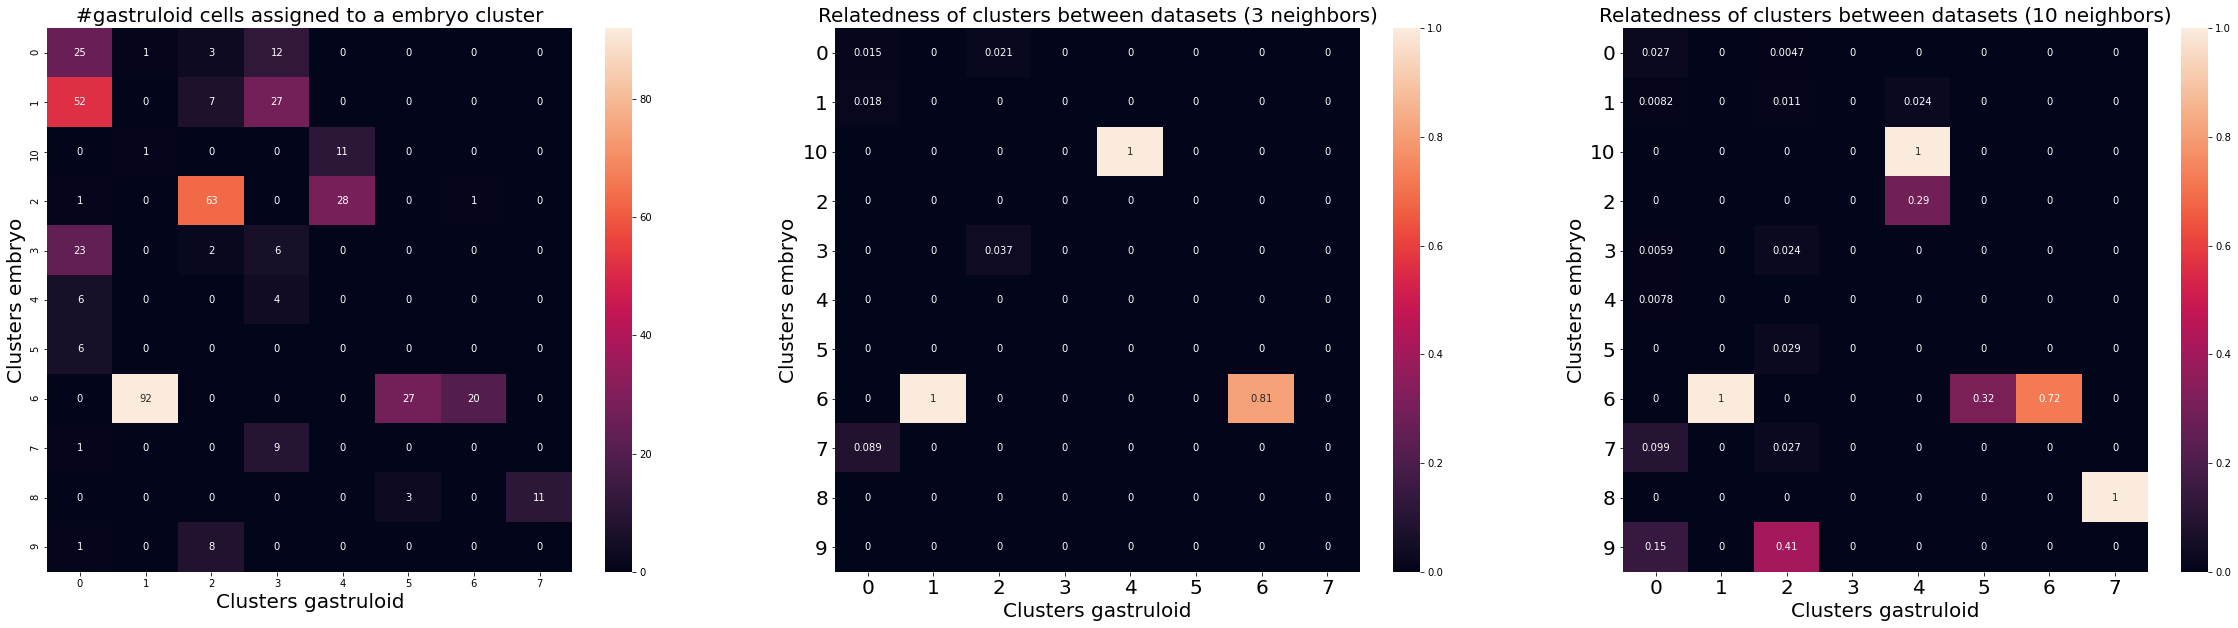

In [50]:
fig,ax = plt.subplots(1,3,figsize=[40,10])

#Plot count matrix
matrix = adata_gastruloid.obs.groupby(["leiden_global","clusters_from_embryo"]).count().iloc[:,0].unstack().transpose()
matrix = matrix.sort_index()
sns.heatmap(matrix,annot=True,ax=ax[0])
ax[0].set_ylabel("Clusters embryo",fontsize=20)
ax[0].set_xlabel("Clusters gastruloid",fontsize=20)
ax[0].set_title("#gastruloid cells assigned to a embryo cluster",fontsize=20)

#Compute paga
scp.pp.highly_variable_genes(adata_integrated)
scp.pp.pca(adata_integrated,n_comps=PCA)
scp.pp.neighbors(adata_integrated,n_neighbors=3,metric="correlation")
scp.tl.paga(adata_integrated,"combined_clusters");
#Get matrix
cat = adata_integrated.obs.loc[:,"combined_clusters"].cat.categories.values
data = pd.DataFrame(adata_integrated.uns["paga"]["connectivities"].todense(),index=cat,columns=cat)
data = data.iloc[:,11:].iloc[:11,:]
data = data.sort_index()
#Plot
sns.heatmap(data,annot=True,ax=ax[1])
labels = ax[1].get_xticklabels()
ax[1].set_xticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
labels = ax[1].get_yticklabels()
ax[1].set_yticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
ax[1].set_ylabel("Clusters embryo",fontsize=20)
ax[1].set_xlabel("Clusters gastruloid",fontsize=20)
ax[1].set_title("Relatedness of clusters between datasets (3 neighbors)",fontsize=20)

#Compute paga
scp.pp.highly_variable_genes(adata_integrated)
scp.pp.pca(adata_integrated,n_comps=PCA)
scp.pp.neighbors(adata_integrated,n_neighbors=10,metric="correlation")
scp.tl.paga(adata_integrated,"combined_clusters");
#Get matrix
cat = adata_integrated.obs.loc[:,"combined_clusters"].cat.categories.values
data = pd.DataFrame(adata_integrated.uns["paga"]["connectivities"].todense(),index=cat,columns=cat)
data = data.iloc[:,11:].iloc[:11,:]
data = data.sort_index()
#Plot
sns.heatmap(data,annot=True,ax=ax[2])
labels = ax[2].get_xticklabels()
ax[2].set_xticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
labels = ax[2].get_yticklabels()
ax[2].set_yticklabels([i.get_text().split("_")[1] for i in labels],fontsize=20)
ax[2].set_ylabel("Clusters embryo",fontsize=20)
ax[2].set_xlabel("Clusters gastruloid",fontsize=20)
ax[2].set_title("Relatedness of clusters between datasets (10 neighbors)",fontsize=20)

fig.savefig("plots/sorted/embryo_projection/relatedness_between_clusters.png",bbox_inches="tight")
fig.show()